In [76]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

train_path = "/Users/anneho/Downloads/chest_xray/chest_xray/train"
test_path = "/Users/anneho/Downloads/chest_xray/chest_xray/test"

In [77]:
change = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()])

train = datasets.ImageFolder(train_path, change)
test = datasets.ImageFolder(test_path, change)
train = DataLoader(train, batch_size=8, shuffle=True)
test = DataLoader(test, batch_size=8)

In [78]:
#CNN
model = nn.Sequential(
    nn.Conv2d(3, 16, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32*14*14, 2))

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001)
losses = []

if epoch = 1 then loss = 0.6957
if epoch = 2 then loss = 0.734
if epoch = 3 then loss = 0.6879
if epoch = 4 then loss = 0.6867
if epoch = 5 then loss = 0.5666
if epoch = 6 then loss = 0.7907
if epoch = 7 then loss = 0.6836
if epoch = 8 then loss = 0.6755
if epoch = 9 then loss = 0.7258
if epoch = 10 then loss = 0.668
if epoch = 11 then loss = 0.6765
if epoch = 12 then loss = 0.6444
if epoch = 13 then loss = 0.6824
if epoch = 14 then loss = 0.6827
if epoch = 15 then loss = 0.6455


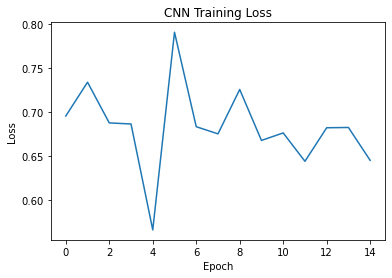

In [79]:
# train data
for i in range(15):

    total_loss = 0
    count = 0

    for image, label in train:
        guess = model(image)
        loss = loss_function(guess,label)
        
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    total_loss += loss.item()
    count += 1

    avg_loss = total_loss / count
    losses.append(avg_loss)

    print( "if epoch =",i+1,"then loss =", round(avg_loss,4))
    
plt.plot(losses)
plt.title("CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()
    

In [80]:
# test accuracy
correct = 0
total = 0

for image, label in test:
    guess = model(image)
    answer = guess.argmax(1)
    correct += (answer == label).sum().item()
    total += len(label)

accuracy = correct / total

Test Accuracy: 78.82 %


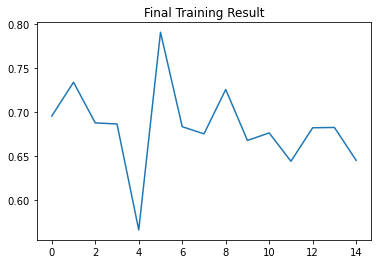

AI Result Display: PNEUMONIA . Recommend follow up with specialist for next steps


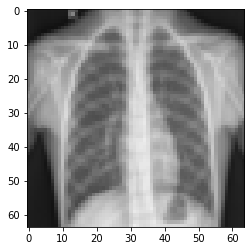

In [82]:
print(
    "Test Accuracy:",
    round(accuracy * 100, 2),"%")

# plot loss
plt.plot(losses)
plt.title("Final Training Result")
plt.show()

#new picture
image, label = next(iter(test))
guess = model(image)
answer = guess.argmax(1)[0]

print("AI Result Display:",test.dataset.classes[answer],".", "Recommend follow up with specialist for next steps")

plt.imshow(image[0].permute(1,2,0))
plt.show()